<a href="https://colab.research.google.com/github/rkuo2000/AI-exercise/blob/main/Wafer_Map_Recognition_ResNet50_with_ASVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import os
os.environ["KAGGLEHUB_CACHE"] = "/content/kagglehub"

import kagglehub
qingyi_wm811k_wafer_map_path = kagglehub.dataset_download('qingyi/wm811k-wafer-map')
co1d7era_mixedtype_wafer_defect_datasets_path = kagglehub.dataset_download('co1d7era/mixedtype-wafer-defect-datasets')

100%|██████████| 149M/149M [00:00<00:00, 173MB/s]

Extracting files...


100%|██████████| 21.8M/21.8M [00:00<00:00, 104MB/s]

Extracting files...


In [2]:
import os
print(os.listdir(qingyi_wm811k_wafer_map_path))
print(os.listdir(co1d7era_mixedtype_wafer_defect_datasets_path))

['LSWMD.pkl']
['Wafer_Map_Datasets.npz', 'Description.pdf']


# Wafer Map Recognition

## Notebook: [Wafer Map Recogntioin using ResNet50 with ASVD](https://www.kaggle.com/code/yashsachan4yrbtech/wafer-map-recognition-using-resent-50-with-asvd/notebook)

## Dataset: [MixedWM38](https://www.kaggle.com/datasets/co1d7era/mixedtype-wafer-defect-datasets)
![](https://www.kaggleusercontent.com/kf/234609705/eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4Q0JDLUhTMjU2In0..cHJf2htIn7rZEzFXIZHDmQ.p2xPWQYbE36ijoT7u0QP-XQ7ie_SArs35fRrtHZkYYBa5ywSCy_B-tqvNUHKSzs_ORvQFlqxWppRNRGgZjfYvXNuaqahPS65bBW3zG-LU-5JaI3lmBvIoL3EpQX7k6LB4yXv_3jQu5SqRwLAREwfAYXyTPJLOl6VraeiWjN2Gv8M41KKFihR74bdUls2vmMCXserGLHCpRtf5rfGAiUs_wEs4GMqjDwe_27WSljMaullXGQqyN_D1TnFRrqt693WSs1FqKZ-EVsKgtUUsUI_tuRPvAw5f4ndc-eKV54-hZuwig9hL5EPe0apyHFUdBkp6-YupYS6uaAQjGcac6x2NLslc4LbSo3EhGpB8AhheA4xHRYSAjCJTAsw-J0I6RD2wLDON9p9C8_-gxxMoyay2FRyulbHj6MBszSpIOo8tQpKMSPcWhwlqasfY3sFUa64Tn5UGPClOZHgH-3lpU-k9C1zw8r9lOCv_obt9o7eNH-xJc3094aEaKceZly5Fq8q_vZLIdvbyqTtcvX6dCT3ZaFxT-Isy51Onz5qmEtc_gb-uLOdOjQ_D4MaOBKXCs4P5ubLjJvIEHKOdRdAJJwCQBkwSzmXzLUU_qBkl8OuCU-VRTzf9p9GIwO7Ioz04h2xLQwCT4GS8zkd7haexl9GtvhubjNns71CWbwaJQAaMk8.H6ECA4Rzfq5Acz71nGqCcg/__results___files/__results___2_3.png)

## 1. Import Libraries & Set Device

In [3]:
import os
import ast
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. RGB Conversion Function & Transform

In [4]:
def convert_to_rgb(image):
    if len(image.shape) == 3 and image.shape[0] == 1:
        image = image.squeeze(0)
    h, w = image.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[image == 0] = [0, 0, 0]
    rgb[image == 1] = [0, 255, 0]
    rgb[image == 2] = [255, 0, 0]
    return rgb

rgb_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.squeeze() if len(x.shape) == 3 and x.shape[0] == 1 else x),
    transforms.Lambda(convert_to_rgb),
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 3. Dataset Classes

In [5]:
# 38-class mapping
classes_dict = {
    "00000000": 0, "10000000": 1, "01000000": 2, "00100000": 3,
    "00010000": 4, "00001000": 5, "00000100": 6, "00000010": 7,
    "00000001": 8, "10100000": 9, "10010000": 10, "10001000": 11,
    "10000010": 12, "01100000": 13, "01010000": 14, "01001000": 15,
    "01000010": 16, "00101000": 17, "00100010": 18, "00011000": 19,
    "00010010": 20, "00001010": 21, "10101000": 22, "10100010": 23,
    "10011000": 24, "10010010": 25, "10001010": 26, "01101000": 27,
    "01100010": 28, "01011000": 29, "01010010": 30, "01001010": 31,
    "00101010": 32, "00011010": 33, "10101010": 34, "10011010": 35,
    "01101010": 36, "01011010": 37
}

class WaferDataset38(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = [
            classes_dict["".join(str(int(x)) for x in one_hot)]
            for one_hot in labels
        ]
        self.transform = transform or rgb_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if len(img.shape) == 3 and img.shape[0] == 1:
            img = img.squeeze(0)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# 8-class mapping for second dataset
failure_mapping = {
    'Center':    [1,0,0,0,0,0,0,0], 'Donut': [0,1,0,0,0,0,0,0],
    'Edge-Loc':  [0,0,1,0,0,0,0,0], 'Edge-Ring': [0,0,0,1,0,0,0,0],
    'Loc':       [0,0,0,0,1,0,0,0], 'Near-full': [0,0,0,0,0,1,0,0],
    'Scratch':   [0,0,0,0,0,0,1,0], 'Random': [0,0,0,0,0,0,0,1],
    'none':      [0,0,0,0,0,0,0,0]
}
strict_mapping = {
    "00000000": 0, "10000000": 1, "01000000": 2, "00100000": 3,
    "00010000": 4, "00001000": 5, "00000100": 6, "00000010": 7,
    "00000001": 8,
}

class SecondWaferDatasetRGB(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform or rgb_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if isinstance(img, str):
            img = np.array(ast.literal_eval(img), dtype=np.uint8)
        else:
            img = np.array(img, dtype=np.uint8)
        if len(img.shape) == 3 and img.shape[0] == 1:
            img = img.squeeze(0)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

## 4. Data Loading & Splitting

In [6]:
# 38-class
data38 = np.load(os.path.join(co1d7era_mixedtype_wafer_defect_datasets_path,"Wafer_Map_Datasets.npz"))
imgs38, labs38 = data38["arr_0"], data38["arr_1"]
i38_tr, i38_te, l38_tr, l38_te = train_test_split(imgs38, labs38, test_size=0.1, random_state=42)
ds38_tr = WaferDataset38(i38_tr, l38_tr)
ds38_te = WaferDataset38(i38_te, l38_te)

# 8-class
df1 = pd.read_pickle(os.path.join(qingyi_wm811k_wafer_map_path,"LSWMD.pkl"))
df1 = df1[df1.failureType.apply(lambda x: len(x) > 0)]
imgs2, labs2 = [], []
for _, row in df1.iterrows():
    wm = row.waferMap
    wm = np.array(ast.literal_eval(wm) if isinstance(wm, str) else wm, dtype=np.uint8)
    failure = row.failureType
    failure = ast.literal_eval(failure) if isinstance(failure, str) else failure
    key = failure[0][0] if hasattr(failure[0], '__iter__') else failure[0]
    oh = failure_mapping.get(key, failure_mapping['none'])
    idx = strict_mapping["".join(str(x) for x in oh)]
    imgs2.append(wm); labs2.append(idx)
i2_tr, i2_te, l2_tr, l2_te = train_test_split(imgs2, labs2, test_size=0.1, random_state=42)
ds2_tr = SecondWaferDatasetRGB(i2_tr, l2_tr)
ds2_te = SecondWaferDatasetRGB(i2_te, l2_te)

# Merge
train_ds = ConcatDataset([ds38_tr, ds2_tr])
test_ds  = ConcatDataset([ds38_te, ds2_te])
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)

## 5. ASVD + Binary-Search Rank Selection

In [7]:
def decompose_conv_svd(conv, rank):
    W = conv.weight.data
    out_ch, in_ch, k, _ = W.shape
    W_flat = W.reshape(out_ch, -1)
    U, S, Vt = torch.svd_lowrank(W_flat, q=rank)
    V = Vt.t().reshape(rank, in_ch, k, k).contiguous()
    conv1 = nn.Conv2d(in_ch, rank, k,
                      stride=conv.stride, padding=conv.padding, bias=False)
    conv1.weight.data.copy_(V)
    W2 = (U * S.unsqueeze(0)).t().reshape(out_ch, rank, 1, 1).contiguous()
    conv2 = nn.Conv2d(rank, out_ch, 1, bias=(conv.bias is not None))
    conv2.weight.data.copy_(W2)
    if conv.bias is not None:
        conv2.bias.data.copy_(conv.bias.data)
    return nn.Sequential(conv1, conv2)

def compute_sensitivities(model, loader, max_batches=1):
    sens = {}
    hooks = []
    def make_hook(name):
        def hook(module, inp, out):
            sens.setdefault(name, []).append(out.abs().mean().item())
        return hook

    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d) and m.kernel_size[0] > 1:
            hooks.append(m.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            model(imgs.to(device))
            if i + 1 >= max_batches: break

    for h in hooks: h.remove()
    return {n: np.mean(v) for n, v in sens.items()}

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def apply_asvd_binary_search(base_model, loader,
                             target_ratio=0.7, rank_ratio=0.5, max_batches=1):
    orig = count_parameters(base_model)
    budget = target_ratio * orig
    sens = compute_sensitivities(base_model, loader, max_batches)
    sorted_layers = sorted(sens, key=sens.get, reverse=True)

    best, best_diff = None, float('inf')
    lo, hi = 0, len(sorted_layers) - 1
    while lo <= hi:
        mid = (lo + hi)//2
        to_decomp = set(sorted_layers[:mid+1])
        m = copy.deepcopy(base_model)
        for name, module in m.named_modules():
            if name in to_decomp and isinstance(module, nn.Conv2d) and module.kernel_size[0] > 1:
                r = max(1, int(rank_ratio * module.out_channels))
                parent, attr = m, name
                for part in name.split('.')[:-1]:
                    parent = getattr(parent, part)
                setattr(parent, name.split('.')[-1], decompose_conv_svd(module, r))
        newp = count_parameters(m)
        diff = newp - budget
        if abs(diff) < best_diff and newp <= orig:
            best_diff, best = abs(diff), m
        if newp > budget:
            lo = mid + 1
        else:
            hi = mid - 1

    return best or base_model

## 6. Build & Optimize Model

In [8]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 38)
model = model.to(device)

# ASVD + binary search to keep 70% of params
model = apply_asvd_binary_search(model, train_loader, target_ratio=0.7, rank_ratio=0.5, max_batches=1)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


## 7. Training Loop

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-5)
epochs = 7

for epoch in range(epochs):
    model.train()
    running_loss = correct = total = 0
    bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", ncols=80)
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        bar.set_postfix(loss=f"{loss.item():.3f}")

    print(f"[Epoch {epoch+1}] Train Loss: {running_loss/total:.4f} | Train Acc: {correct/total:.4f}")

Epoch 1/7: 100%|████████████████| 2967/2967 [31:05<00:00,  1.59it/s, loss=0.216]


[Epoch 1] Train Loss: 0.4928 | Train Acc: 0.8800


Epoch 2/7: 100%|████████████████| 2967/2967 [31:10<00:00,  1.59it/s, loss=0.308]


[Epoch 2] Train Loss: 0.1542 | Train Acc: 0.9582


Epoch 3/7: 100%|████████████████| 2967/2967 [31:09<00:00,  1.59it/s, loss=0.051]


...

[Epoch 5] Train Loss: 0.0493 | Train Acc: 0.9858


Epoch 6/7: 100%|████████████████| 2967/2967 [31:10<00:00,  1.59it/s, loss=0.011]


[Epoch 6] Train Loss: 0.0376 | Train Acc: 0.9893


Epoch 7/7: 100%|████████████████| 2967/2967 [31:11<00:00,  1.59it/s, loss=0.012]

[Epoch 7] Train Loss: 0.0295 | Train Acc: 0.9917


## 8. Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14928
           1       0.93      0.95      0.94       579
           2       0.92      0.91      0.92       145
           3       0.79      0.82      0.81       572
           4       0.97      0.97      0.97      1010
           5       0.88      0.70      0.78       472
           6       0.86      0.91      0.89        35
           7       0.87      0.77      0.82       233
           8       0.95      0.90      0.93       166
           9       0.98      0.99      0.98        94
          10       0.97      0.99      0.98        87
          11       0.97      0.97      0.97        94
          12       0.97      1.00      0.98        90
          13       0.96      0.97      0.97       102
          14       0.96      0.99      0.97        95
          15       0.99      0.98      0.98        95
          16       0.92      0.99      0.96        97
    

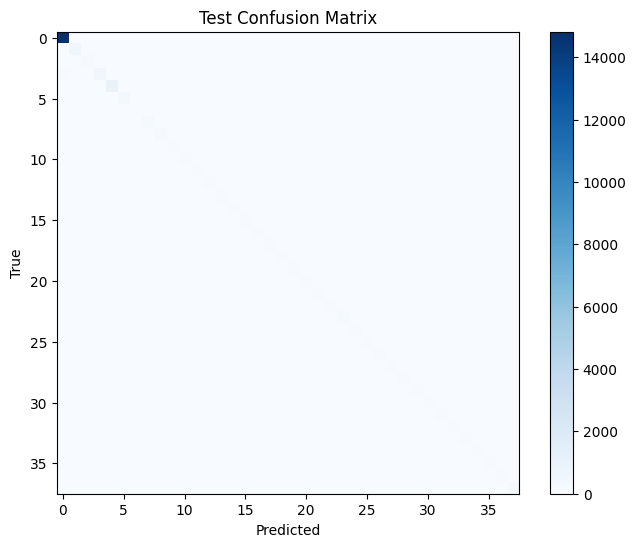

In [10]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Test Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 9. Evaluate the Model on the Full 38‑Class Dataset

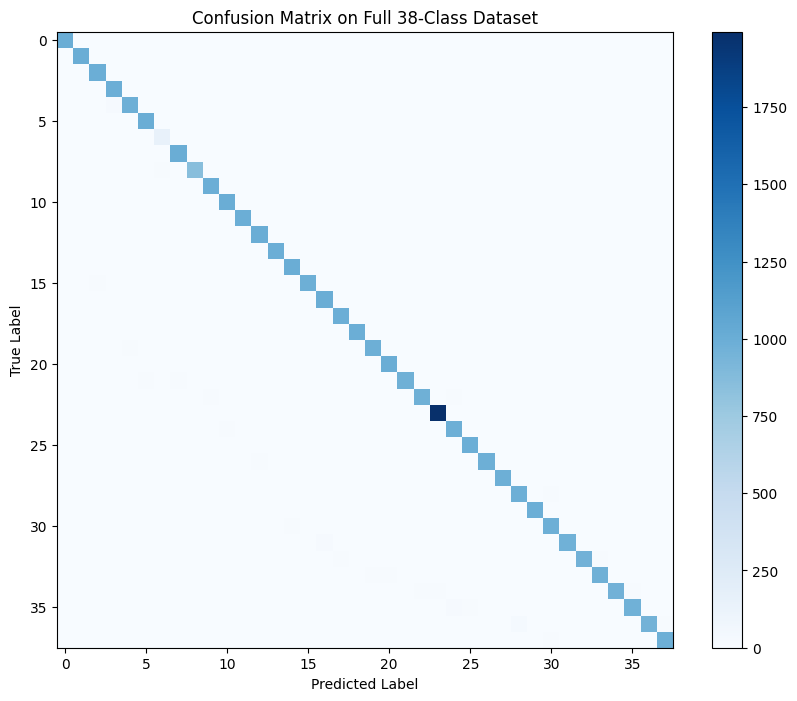

Classification Report on Full 38‑Class Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       0.99      1.00      1.00      1000
           2       0.98      0.99      0.99      1000
           3       0.97      0.99      0.98      1000
           4       0.99      0.98      0.98      1000
           5       0.99      1.00      0.99      1000
           6       0.94      0.99      0.96       149
           7       0.99      1.00      1.00      1000
           8       1.00      0.98      0.99       866
           9       0.99      0.99      0.99      1000
          10       0.98      1.00      0.99      1000
          11       0.99      0.99      0.99      1000
          12       0.99      1.00      0.99      1000
          13       0.99      0.99      0.99      1000
          14       0.98      1.00      0.99      1000
          15       0.99      0.99      0.99      1000
          16       0.97      1.00

In [11]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 9.1 Create a DataLoader for the full 38‑class dataset
#    images38, labs38 were loaded earlier from the NPZ
full_dataset_38 = WaferDataset38(imgs38, labs38, transform=rgb_transform)
full_loader_38 = DataLoader(
    full_dataset_38,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

model.eval()  # Switch to evaluation mode

all_preds_full = []
all_labels_full = []

# 9.2 Start timing before predictions
start_time = time.time()

with torch.no_grad():
    for images, labels in full_loader_38:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds_full.extend(preds.cpu().numpy())
        all_labels_full.extend(labels.numpy())

# 9.3 End timing after predictions
end_time = time.time()
total_time = end_time - start_time

all_preds_full = np.array(all_preds_full)
all_labels_full = np.array(all_labels_full)

# 9.4 Confusion Matrix
cm_full = confusion_matrix(all_labels_full, all_preds_full)
plt.figure(figsize=(10, 8))
plt.imshow(cm_full, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix on Full 38‑Class Dataset")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 9.5 Classification Report
print("Classification Report on Full 38‑Class Dataset:")
print(classification_report(all_labels_full, all_preds_full))

# 9.6 Total prediction time
print(f"Total prediction time on full 38‑class dataset: {total_time:.2f} seconds")